# Cartão na Era Digital: por que não competimos com o PIX no presencial, e onde o cartão é imbatível

> Esta análise usa **exclusivamente dados internos** (`Base_transacoes`, `Base_pix`, `Base_clientes`).
>
> **Estrutura:**
> - **Parte A — Refutação:** os dados mostram que tentar trazer o pagamento *presencial* de volta para o cartão (mesmo "digitalizado") é uma batalha perdida para o PIX.
> - **Parte B — Contraproposta:** o cartão deve crescer onde o PIX, por desenho, **não entra** — online (CNP), internacional, recorrência e carteira digital. Dimensionamento com a composição atual da base.
>
> **Nota metodológica:** o ticket das transações de 2024 é um artefato (~2,5× o de 2023/2025). Por isso as comparações temporais priorizam **quantidade** de transações e os trimestres 2023/2025. Os PIX de 2025Q1–Q2 estão ausentes do dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
MC_RED, MC_ORANGE, MC_DARK, GREY = '#EB001B', '#F79E1B', '#1A1A2E', '#9E9E9E'

# resolve a pasta de dados rode de onde rodar
DATA = next(p for p in [Path('../data'), Path('data'), Path('./data')] if p.exists())
OUT = Path('graficos'); OUT.mkdir(exist_ok=True)
print('Dados em:', DATA.resolve())

# ---- Cartão ----
tx = pd.read_csv(DATA/'Base_transacoes.csv')
tx['Data'] = pd.to_datetime(tx['Data'], errors='coerce')
tx = tx[(tx['Valor_Compra'] > 0) & tx['Data'].notna()].copy()
tx['q'] = tx['Data'].dt.to_period('Q').astype(str)
tx['ano'] = tx['Data'].dt.year

# ---- PIX ----
pix = pd.read_csv(DATA/'Base_pix.csv')
pix['Data'] = pd.to_datetime(pix['Data'], errors='coerce')
pix = pix[(pix['Valor'] > 0) & pix['Data'].notna()].copy()
pix['q'] = pix['Data'].dt.to_period('Q').astype(str)

# ---- Clientes ----
cli = pd.read_csv(DATA/'Base_clientes.csv')
cli['Data_Nascimento'] = pd.to_datetime(cli['Data_Nascimento'], dayfirst=True, errors='coerce')
cli['idade'] = (pd.Timestamp('2025-12-31') - cli['Data_Nascimento']).dt.days // 365
cli['faixa'] = pd.cut(cli['idade'], [0,29,39,49,59,69,200],
                      labels=['18-29','30-39','40-49','50-59','60-69','70+'])

print(f'Transações cartão: {len(tx):,} | PIX: {len(pix):,} | Clientes: {len(cli):,}')

Dados em: /Users/siqs/Hackathon Mastercard/Mastercaras/data
Transações cartão: 156,661 | PIX: 277,432 | Clientes: 1,960


---
## Parte A — Por que NÃO competimos com o PIX no presencial

A tentação óbvia é "trazer o pagamento de volta para o cartão" — inclusive o presencial, via Apple Pay/contactless. Os dados mostram por que isso é correr atrás do prejuízo: **o presencial é o terreno onde o PIX já venceu.**


### A.1 — A inversão cartão → PIX em 2025

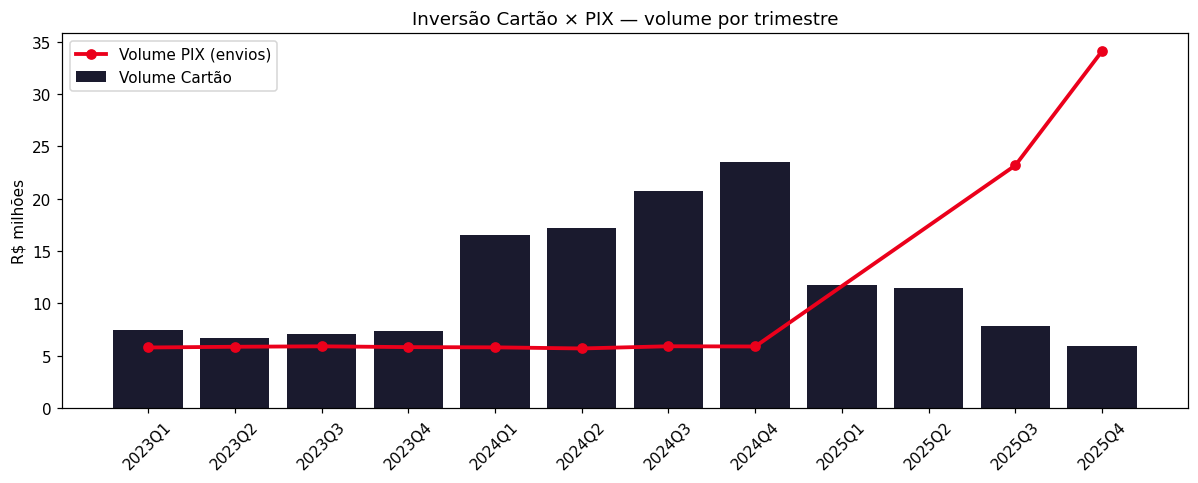

Cartão: pico R$ 23.5M (2024Q4) -> R$ 5.9M (2025Q4) = -75%
PIX 2025Q4: R$ 34.1M  (vs ~R$5,5M/tri estável até 2024)


In [4]:
card_q = tx.groupby('q')['Valor_Compra'].agg(vol='sum', n='count')
env = pix[pix['Tipo_transacao'] == 'Envio']
pix_q = env.groupby('q')['Valor'].agg(vol='sum', n='count')

fig, ax = plt.subplots(figsize=(11,4.5))
ax.bar(card_q.index, card_q['vol']/1e6, color=MC_DARK, label='Volume Cartão')
ax.plot(pix_q.index, pix_q['vol']/1e6, color=MC_RED, marker='o', lw=2.5, label='Volume PIX (envios)')
ax.set_ylabel('R$ milhões'); ax.set_title('Inversão Cartão × PIX — volume por trimestre')
ax.legend(); ax.tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.savefig(OUT/'A1_inversao.png', bbox_inches='tight'); plt.show()

pico, fim = card_q.loc['2024Q4','vol'], card_q.loc['2025Q4','vol']
print(f"Cartão: pico R$ {pico/1e6:.1f}M (2024Q4) -> R$ {fim/1e6:.1f}M (2025Q4) = {100*(fim/pico-1):.0f}%")
print(f"PIX 2025Q4: R$ {pix_q.loc['2025Q4','vol']/1e6:.1f}M  (vs ~R$5,5M/tri estável até 2024)")

> **Nota:** o degrau de volume de cartão em 2024 vem do ticket inflado (artefato). Por isso a leitura honesta foca na **quantidade** e no recuo de 2025. Ainda assim, a queda 2024Q4→2025Q4 e a explosão do PIX são inequívocas.

### A.2 — O PIX para empresas (PJ) já é maior que TODO o cartão

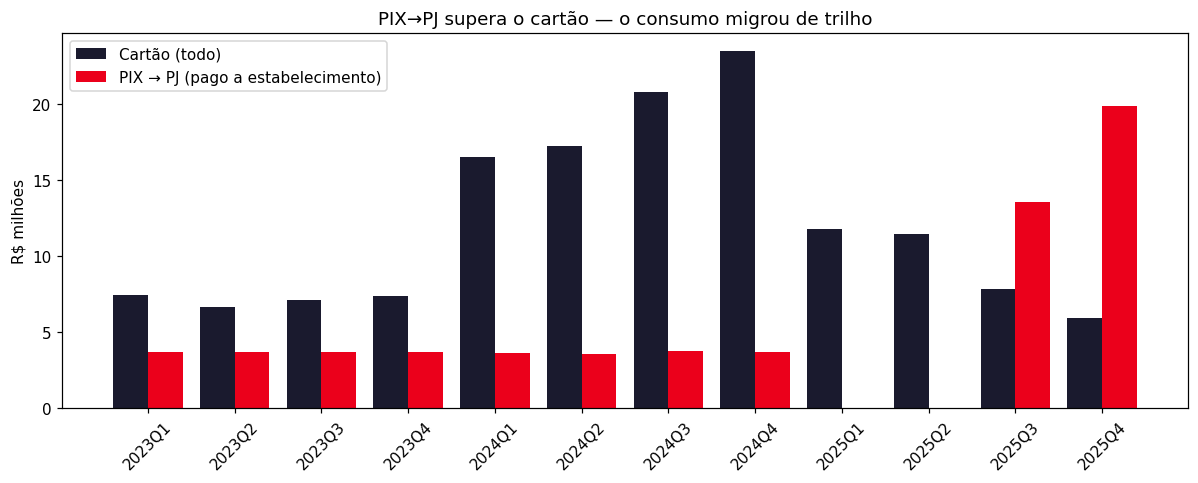

Razão PIX-PJ / Cartão:
q
2023Q1    0.49
2023Q2    0.56
2023Q3    0.52
2023Q4    0.50
2024Q1    0.22
2024Q2    0.21
2024Q3    0.18
2024Q4    0.16
2025Q3    1.73
2025Q4    3.36

Em 2025Q4 o PIX para estabelecimentos é 3.4× todo o volume de cartão.


In [5]:
pj = env[env['PF_PJ'] == 'PJ']
pj_q = pj.groupby('q')['Valor'].agg(vol='sum', n='count')
comp = card_q[['vol']].rename(columns={'vol':'cartao'}).join(pj_q['vol'].rename('pix_pj'))
comp['razao'] = comp['pix_pj'] / comp['cartao']

fig, ax = plt.subplots(figsize=(11,4.5))
x = np.arange(len(comp)); w = 0.4
ax.bar(x-w/2, comp['cartao']/1e6, w, color=MC_DARK, label='Cartão (todo)')
ax.bar(x+w/2, comp['pix_pj']/1e6, w, color=MC_RED, label='PIX → PJ (pago a estabelecimento)')
ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=45)
ax.set_ylabel('R$ milhões'); ax.set_title('PIX→PJ supera o cartão — o consumo migrou de trilho')
ax.legend(); plt.tight_layout(); plt.savefig(OUT/'A2_pixpj_vs_cartao.png', bbox_inches='tight'); plt.show()

print("Razão PIX-PJ / Cartão:")
print(comp['razao'].dropna().round(2).to_string())
print(f"\nEm 2025Q4 o PIX para estabelecimentos é {comp.loc['2025Q4','razao']:.1f}× todo o volume de cartão.")

### A.3 — 70% do volume de cartão é presencial: a fatia exata que o PIX está comendo

Composição das transações de cartão:
  CP  (presencial): 70.0% das transações | 70.0% do valor
  CNP (online):     30.0% das transações | 30.0% do valor


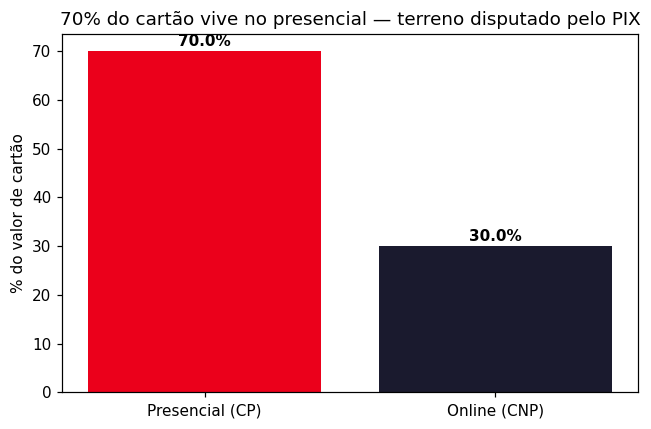

In [6]:
mix = tx['Tipo_Compra'].value_counts(normalize=True).mul(100).round(1)
val = tx.groupby('Tipo_Compra')['Valor_Compra'].sum()
val_pct = (val/val.sum()*100).round(1)
print("Composição das transações de cartão:")
print(f"  CP  (presencial): {mix.get('CP')}% das transações | {val_pct.get('CP')}% do valor")
print(f"  CNP (online):     {mix.get('CNP')}% das transações | {val_pct.get('CNP')}% do valor")

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Presencial (CP)','Online (CNP)'], [val_pct.get('CP'), val_pct.get('CNP')],
       color=[MC_RED, MC_DARK])
ax.set_ylabel('% do valor de cartão')
ax.set_title('70% do cartão vive no presencial — terreno disputado pelo PIX')
for i,v in enumerate([val_pct.get('CP'), val_pct.get('CNP')]):
    ax.text(i, v+1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig(OUT/'A3_cp_vs_cnp.png', bbox_inches='tight'); plt.show()

### A.4 — A migração é transversal: todas as idades já pagam PJ no PIX

       %_valor_PIX_para_PJ  razao_PIX/Cartao_por_cliente
faixa                                                   
18-29                 61.9                           2.9
30-39                 60.6                           1.5
40-49                 59.8                           1.5
50-59                 60.9                           1.4
60-69                 60.0                           1.4
70+                   58.8                           1.7


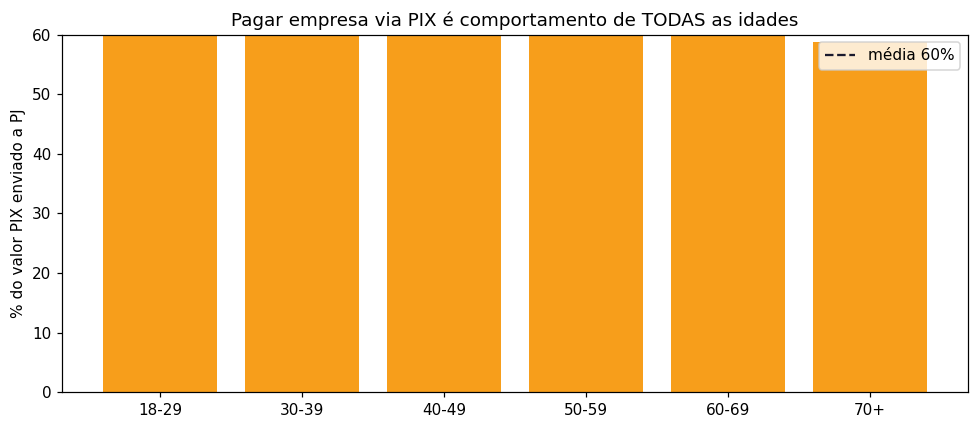

In [7]:
env_pj = env[env['PF_PJ']=='PJ'].merge(cli[['Cliente_ID','faixa']], on='Cliente_ID', how='left')
env_all = env.merge(cli[['Cliente_ID','faixa']], on='Cliente_ID', how='left')

# % do valor enviado que vai para PJ, por faixa
pj_share = (env_pj.groupby('faixa', observed=True)['Valor'].sum() /
            env_all.groupby('faixa', observed=True)['Valor'].sum() * 100).round(1)
# razão de QTD PIX / QTD cartão por cliente, por faixa
pix_cli = env.merge(cli[['Cliente_ID','faixa']],on='Cliente_ID').groupby('faixa',observed=True)['Valor'].count()
card_cli = tx.merge(cli[['Cliente_ID','faixa']],on='Cliente_ID').groupby('faixa',observed=True)['Valor_Compra'].count()
n_pix = cli[cli['Cliente_ID'].isin(env['Cliente_ID'])].groupby('faixa',observed=True).size()
n_card = cli[cli['Cliente_ID'].isin(tx['Cliente_ID'])].groupby('faixa',observed=True).size()
razao = ((pix_cli/n_pix) / (card_cli/n_card)).round(1)

tab = pd.DataFrame({'%_valor_PIX_para_PJ': pj_share, 'razao_PIX/Cartao_por_cliente': razao})
print(tab.to_string())

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(pj_share.index.astype(str), pj_share.values, color=MC_ORANGE)
ax.axhline(pj_share.mean(), color=MC_DARK, ls='--', label=f'média {pj_share.mean():.0f}%')
ax.set_ylabel('% do valor PIX enviado a PJ'); ax.set_ylim(0,60)
ax.set_title('Pagar empresa via PIX é comportamento de TODAS as idades')
ax.legend(); plt.tight_layout(); plt.savefig(OUT/'A4_transversal.png', bbox_inches='tight'); plt.show()


Os dados **refutam** a ideia de competir com o PIX no presencial:

1. **O presencial já é do PIX.** Em 2025Q4 o PIX→PJ é **~3,4× todo o volume de cartão** — e cresce, enquanto o cartão cai 75%.
2. **É exatamente onde estamos expostos:** ~70% do nosso valor de cartão é presencial (CP) — a fatia atacada.
3. **Não é nicho, é a base inteira:** ~47–49% do PIX de **toda** faixa etária vai para PJ. Não há segmento "imune" para defender no presencial.
4. **A economia favorece o PIX no balcão:** para o lojista, PIX tem custo de aceitação próximo de zero (sem MDR); "cartão digitalizado" no presencial não muda esse incentivo. Brigar aqui é empurrar contra a maré.

**Implicação:** não devemos gastar bala tentando reconverter o pagamento de balcão. Devemos mudar o campo de batalha.


---
## Parte B — Crescer o cartão onde o PIX não entra

O PIX é doméstico, em tempo real e irreversível. Por **desenho**, ele não resolve quatro contextos onde o cartão é a melhor (ou única) opção. A estratégia é levar o cartão — digitalizado — para esses territórios.

| Território PIX-proof | Por que o PIX não entra |
|---|---|
| **Internacional (crossborder)** | PIX é só BRL/doméstico |
| **E-commerce / online (CNP)** | checkout tokenizado, 1-clique |
| **Recorrência / assinaturas** | cobrança automática agendada |
| **Proteção ao comprador** | PIX é irreversível, sem chargeback |

A seguir, dimensionamos cada um com a **composição atual** da base.


### B.1 — quão analógico é o nosso cartão

Carteira digital (Apple/Google/Samsung Pay): 14.1% das transações
Online (CNP):  30.0% do valor
Presencial:    70.0% do valor


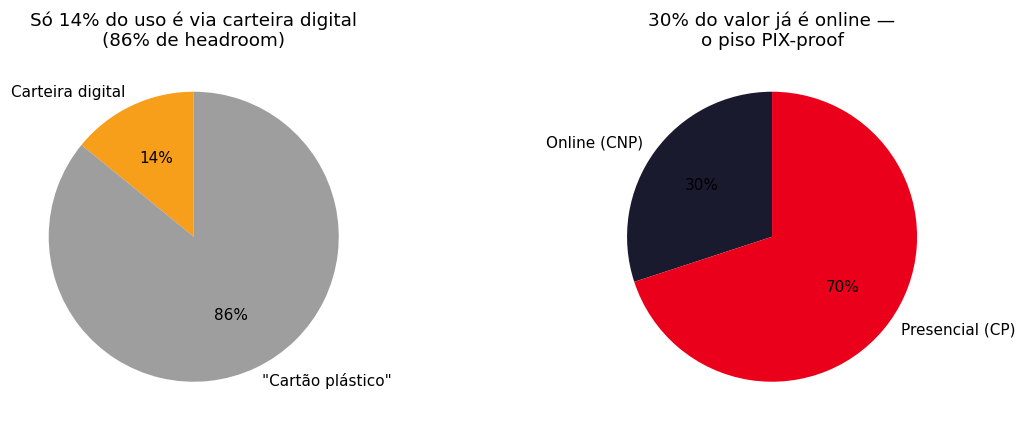

In [8]:
tot_val = tx['Valor_Compra'].sum()
cnp_val   = tx.loc[tx['Tipo_Compra']=='CNP','Valor_Compra'].sum()
wall_val  = tx.loc[tx['Wallet'].notna(),'Valor_Compra'].sum()
wall_share = tx['Wallet'].notna().mean()*100

print(f"Carteira digital (Apple/Google/Samsung Pay): {wall_share:.1f}% das transações")
print(f"Online (CNP):  {100*cnp_val/tot_val:.1f}% do valor")
print(f"Presencial:    {100*(tot_val-cnp_val)/tot_val:.1f}% do valor")

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].pie([wall_share, 100-wall_share], labels=['Carteira digital','"Cartão plástico"'],
            colors=[MC_ORANGE, GREY], autopct='%1.0f%%', startangle=90)
axes[0].set_title('Só 14% do uso é via carteira digital\n(86% de headroom)')
axes[1].pie([cnp_val, tot_val-cnp_val], labels=['Online (CNP)','Presencial (CP)'],
            colors=[MC_DARK, MC_RED], autopct='%1.0f%%', startangle=90)
axes[1].set_title('30% do valor já é online —\no piso PIX-proof')
plt.tight_layout(); plt.savefig(OUT/'B1_foto_digital.png', bbox_inches='tight'); plt.show()

### B.2 — O piso defensável: online + internacional já valem quanto?

In [9]:
# valor anual (usa 2023 e 2025, sem o artefato de 2024)
base = tx[tx['ano'].isin([2023,2025])]
val_ano = base.groupby('ano')['Valor_Compra'].sum()
cnp_ano = base[base['Tipo_Compra']=='CNP'].groupby('ano')['Valor_Compra'].sum()

# internacional: estimativa via taxa entre crossborder preenchidos aplicada ao CNP
cb = base[base['Crossborder'].notna()]
taxa_intl = (cb['Crossborder']==1).mean()
print(f"Entre as transações com crossborder informado, {100*taxa_intl:.0f}% são internacionais.")
print(f"\nValor ONLINE (CNP) por ano (R$ M):")
print((cnp_ano/1e6).round(1).to_string())
print(f"\nPiso PIX-proof hoje (online): ~R$ {cnp_ano.mean()/1e6:.1f}M/ano de valor que o PIX dificilmente alcança.")

Entre as transações com crossborder informado, 50% são internacionais.

Valor ONLINE (CNP) por ano (R$ M):
ano
2023     8.6
2025    11.0

Piso PIX-proof hoje (online): ~R$ 9.8M/ano de valor que o PIX dificilmente alcança.


> **Leitura:** mesmo com a queda geral, há um piso de ~30% do valor que já roda online — terreno onde o PIX é fraco. É a base sobre a qual crescer, em vez do presencial em queda livre.

### B.3 — A maior alavanca: carteira digital parada em 14%

Adoção de carteira digital por trimestre (%):
q
2023Q1    13.7
2023Q2    14.3
2023Q3    14.3
2023Q4    14.2
2024Q1    13.9
2024Q2    14.0
2024Q3    14.1
2024Q4    14.0
2025Q1    14.1
2025Q2    14.5
2025Q3    13.8
2025Q4    14.0

Média: 14.1% — estável e baixa. Cada ponto recuperado é volume que volta ao trilho do cartão.


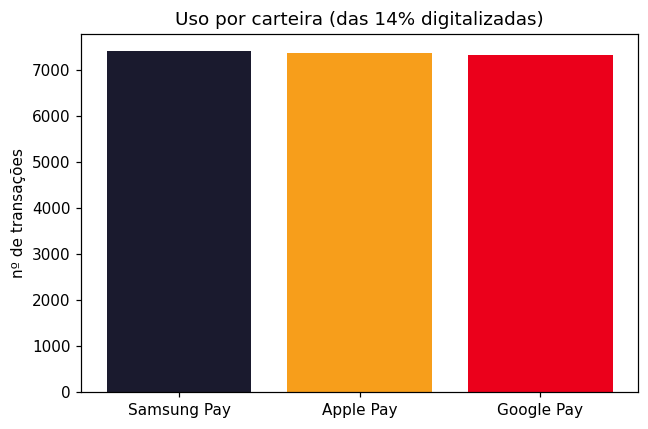

In [10]:
wall_q = tx.groupby('q').apply(lambda d: d['Wallet'].notna().mean()*100, include_groups=False)
print("Adoção de carteira digital por trimestre (%):")
print(wall_q.round(1).to_string())
print(f"\nMédia: {wall_q.mean():.1f}% — estável e baixa. Cada ponto recuperado é volume que volta ao trilho do cartão.")

# distribuição das 3 wallets
w = tx['Wallet'].value_counts()
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(w.index, w.values, color=[MC_DARK, MC_ORANGE, MC_RED])
ax.set_ylabel('nº de transações'); ax.set_title('Uso por carteira (das 14% digitalizadas)')
plt.tight_layout(); plt.savefig(OUT/'B3_wallets.png', bbox_inches='tight'); plt.show()

### B.4 — Recorrência e e-commerce: trilhos que o PIX não cobre

Modos de entrada 'online/remoto' (PIX-proof):
Input_Mode
Phone Order    9555
eCommerce      9533
MasterPass     9416
Recurring      9262
Mail Order     9229

Total remoto: 46,995 transações (30% do cartão)
  dos quais RECORRENTES: 9,262 — receita previsível, que o PIX avulso não captura


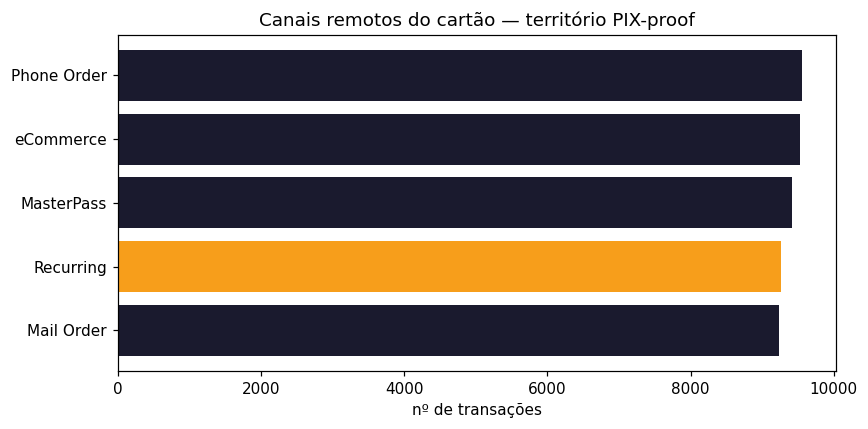

In [11]:
online_modes = ['eCommerce','MasterPass','Phone Order','Mail Order','Recurring']
im = tx['Input_Mode'].value_counts()
im_online = im[im.index.isin(online_modes)]
print("Modos de entrada 'online/remoto' (PIX-proof):")
print(im_online.to_string())
print(f"\nTotal remoto: {im_online.sum():,} transações ({100*im_online.sum()/len(tx):.0f}% do cartão)")
print(f"  dos quais RECORRENTES: {im.get('Recurring',0):,} — receita previsível, que o PIX avulso não captura")

fig, ax = plt.subplots(figsize=(8,4))
colors = [MC_ORANGE if m=='Recurring' else MC_DARK for m in im_online.index]
ax.barh(im_online.index[::-1], im_online.values[::-1], color=colors[::-1])
ax.set_xlabel('nº de transações'); ax.set_title('Canais remotos do cartão — território PIX-proof')
plt.tight_layout(); plt.savefig(OUT/'B4_remoto.png', bbox_inches='tight'); plt.show()

### B.5 — Conclusão da Parte B (contraproposta)

Com dados internos, a estratégia do cartão deixa de ser "reconquistar o balcão" e passa a ser **dominar o digital PIX-proof**:

1. **Carteira digital (14% → meta agressiva):** a maior alavanca. 86% das transações ainda não usam Apple/Google Pay — provisionar a credencial tokenizada traz conveniência ao online e ao presencial de alto valor sem depender de vencer o PIX no cafezinho.
2. **Online / e-commerce (30% do valor):** piso defensável e em expansão estrutural — investir em checkout 1-clique, tokenização e cartão virtual.
3. **Recorrência / assinaturas:** receita previsível que o PIX avulso não captura.
4. **Internacional:** território 100% do cartão — o PIX simplesmente não vai lá.

> **Mensagem:** não vamos brigar pelo pagamento que o PIX já venceu (presencial, miúdo, doméstico). Vamos crescer o cartão onde ele é insubstituível — e digitalizá-lo (carteira + online + recorrência + internacional) para que esse território seja nosso.

*Notebook gerado para a Parte 2 do plano de ação · dados internos Priceless Bank.*
